# [TEMP] 3. Scheduling: Chunked Prefill and the Prefill–Decode Interference

Lecture 2 batched requests together, but a batch can mix two very different
kinds of work: decode steps (1 token each) and prefills (hundreds or
thousands of tokens each). When a 4,000-token prompt arrives and is prefilled
in one step, every request currently decoding in that batch has to wait for it.
Their users see the text stream **stall**.

**Chunked prefill**, introduced by Sarathi-Serve and now the default in vLLM V1,
bounds the work in each step with a **token budget** (`chunk_size`):

1. Every running request gets its next decode token first.
2. Whatever budget is left goes to prefills, splitting long prompts into
   chunks across several steps if needed.

A small budget keeps every step short, so decodes never stall, but long prompts
take many steps to prefill. A large budget does the reverse.

:::{admonition} Learning goals
- Explain how one long prefill inflates the decode latency of every co-scheduled request.
- Use `chunk_size` to trade TTFT against tail TPOT.
- Explain why this trade-off becomes sharper under heavy load.
:::

## Setup

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import vidur_lab as vl
except ImportError:
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/vidur_lab.py",
        "vidur_lab.py")
    import vidur_lab as vl
vl.setup()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

Vidur-Agent ready at /home/kiwan/vidur-agent/Vidur-Agent


## A mixed workload

85% of requests are chat turns (256 tokens in, 256 out) and 15% are long-document
requests (3,800 tokens in, 32 out), arriving in random order.
`vl.make_trace` writes per-request lengths to a trace file that the simulator
replays.

In [2]:
rng = np.random.default_rng(0)
n = 300
is_long = rng.random(n) < 0.15
trace = vl.make_trace(prefill_tokens=np.where(is_long, 3800, 256),
                      decode_tokens=np.where(is_long, 32, 256), n=n, name="mixed")
pd.read_csv(trace).value_counts().rename("requests")

num_prefill_tokens  num_decode_tokens
256                 256                  255
3800                32                    45
Name: requests, dtype: int64

## Sweeping the token budget

We run the same trace at a moderate load (4 req/s) and a heavy load (8 req/s),
varying `chunk_size` from 128 to 4,096 tokens per step.

In [3]:
chunks = [128, 256, 512, 1024, 2048, 4096]
cols = ["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "TPOT p99 (ms)", "throughput (tok/s)"]
res = {q: vl.sweep("chunk_size", chunks, trace=trace, num_requests=n, qps=q) for q in (4, 8)}
res[8][cols]

,TTFT p50 (ms),TTFT p99 (ms),TPOT p50 (ms),TPOT p99 (ms),throughput (tok/s)
chunk_size,,,,,
128.0,6195.680,11799.240,19.509,20.205,6232.642
256.0,1078.840,2856.412,29.606,30.540,7660.500
512.0,358.724,1385.784,37.079,49.769,7863.659
1024.0,244.600,1011.502,42.779,72.425,7814.939
2048.0,178.214,865.638,44.042,83.338,7804.114
4096.0,164.413,1019.335,48.102,86.063,7771.576


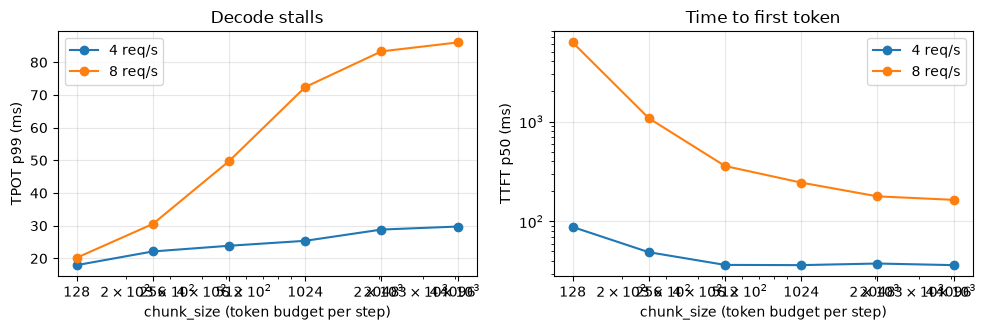

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for q, df in res.items():
    ax[0].plot(chunks, df["TPOT p99 (ms)"], "o-", label=f"{q} req/s")
    ax[1].plot(chunks, df["TTFT p50 (ms)"], "o-", label=f"{q} req/s")
ax[0].set(xscale="log", xlabel="chunk_size (token budget per step)", ylabel="TPOT p99 (ms)",
          title="Decode stalls")
ax[1].set(xscale="log", yscale="log", xlabel="chunk_size (token budget per step)",
          ylabel="TTFT p50 (ms)", title="Time to first token")
for a in ax:
    a.set_xticks(chunks, chunks); a.legend()
fig.tight_layout()

Read the heavy-load (8 req/s) curves from right to left:

- **Large budget (4,096).** A whole 3,800-token prompt fits in one step. Each
  long request reaches its first token quickly, but every request decoding
  alongside it waits for that step to finish. Tail TPOT is more than 4× what the
  smallest budget achieves.
- **Medium budget (512).** Long prompts are split into ~8 chunks. p99 TPOT falls
  by ~40%, while median TTFT roughly doubles but stays well under a second.
- **Tiny budget (128).** Steps are so small that the GPU is badly underused:
  each step re-reads all the weights to process only 128 tokens. Prefill
  throughput collapses, requests pile up in the queue, and TTFT explodes into
  seconds.

At 4 req/s, the GPU has headroom and the trade-off is milder. **Scheduling
matters most when the system is busy.**

## Who pays for the stall?

Split TPOT by request type, with a medium and the largest budget.

In [5]:
for c in (512, 4096):
    r = vl.simulate(trace=trace, num_requests=n, qps=8, chunk_size=c)
    kind = np.where(r.requests["request_num_prefill_tokens"] > 1000, "long-doc", "chat")
    print(f"chunk_size={c}")
    print((1e3 * r.tpot.groupby(kind).describe(percentiles=[.5, .99])[["50%", "99%"]])
          .round(1).rename(columns={"50%": "TPOT p50 (ms)", "99%": "TPOT p99 (ms)"}), "\n")

chunk_size=512
          TPOT p50 (ms)  TPOT p99 (ms)
chat               36.7           41.3
long-doc           40.8           51.2 



chunk_size=4096
          TPOT p50 (ms)  TPOT p99 (ms)
chat               48.2           58.1
long-doc           47.4           88.3 



Both kinds of request slow down with the large budget. Look at the **chat**
requests: none of them has a long prompt, yet their median TPOT rises by about
30%, only because they share steps with *other users'* long prefills. This
interference is what makes it hard to give latency guarantees on a shared GPU.

## Exercises

:::{admonition} Try it
:class: exercise
1. Raise the fraction of long requests to 40%. Does the best `chunk_size` for
   p99 TPOT change?
2. Suppose your SLO is p99 TTFT < 2 s **and** p99 TPOT < 50 ms. Find the
   largest `qps` you can sustain, and the `chunk_size` that achieves it.
3. A different fix is to never mix the two kinds of work: run prefills and
   decodes on *separate* GPUs. This is prefill–decode disaggregation, covered in
   {doc}`06-pd-disaggregation`. What new cost does it introduce?
:::